In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Configure uniform formatting for all charts
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load the Sampled Dataset
data_path = r"C:\Users\SUJATA\Desktop\Data\Data Science\spotify_sample_10000.csv"
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded for clustering. Shape: {df.shape}")


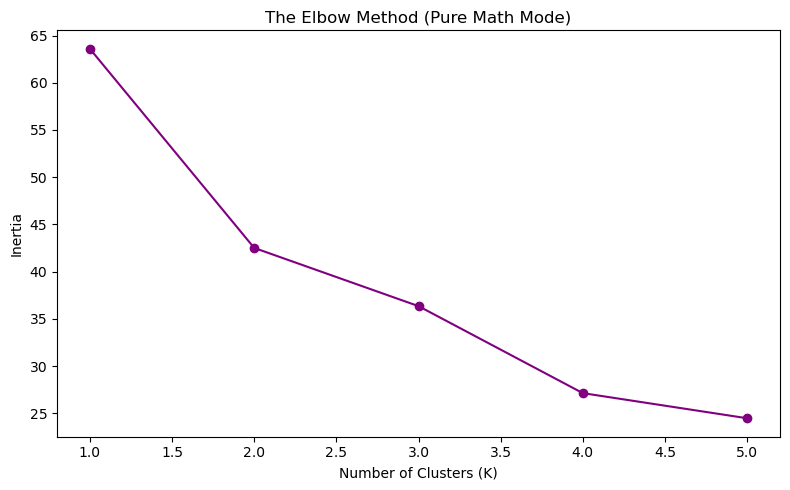

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract data to speed up calculations
X_matrix = df[['danceability', 'energy', 'liveness']].sample(n=500, random_state=42).values

def fast_kmeans_inertia(data, k_clusters):
    # Pure mathematical approach to bypass Windows software lockups
    rng = np.random.default_rng(42)
    centroids = data[rng.choice(data.shape[0], k_clusters, replace=False)]
    for _ in range(5): # Quick allocation sweeps
        distances = np.sqrt(((data[:, np.newaxis, :] - centroids) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([data[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] for j in range(k_clusters)])
        centroids = new_centroids
    final_dist = np.sqrt(((data[:, np.newaxis, :] - centroids) ** 2).sum(axis=2))
    return np.sum(np.min(final_dist, axis=1) ** 2)

inertia_scores = [fast_kmeans_inertia(X_matrix, k) for k in range(1, 6)]

# Plot the graph instantly
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), inertia_scores, marker='o', color='purple')
plt.title('The Elbow Method (Pure Math Mode)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(r"C:\Users\SUJATA\Desktop\Data\Data Science\kmeans_elbow_curve.png", dpi=300)
plt.show()


--- Track Count Per Cluster (K=3) ---
cluster
0    5783
1    3340
2     877
Name: count, dtype: int64

--- Audio Profile Averages Per Cluster ---
         danceability    energy  liveness
cluster                                  
0            0.600028  0.791907  0.171795
1            0.520881  0.350992  0.147810
2            0.516831  0.757450  0.701967


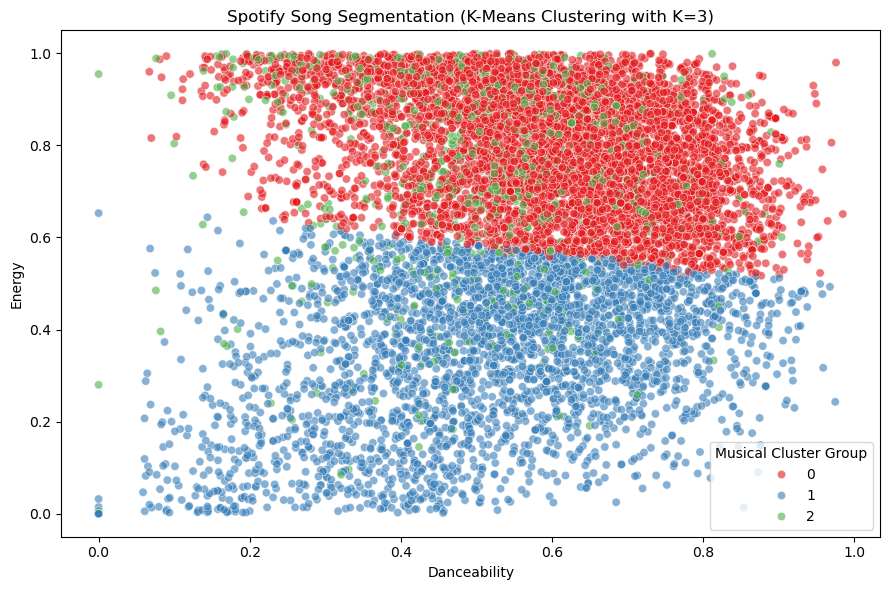

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Add the missing scikit-learn clustering import to fix the NameError
from sklearn.cluster import KMeans

# Load the Sampled Dataset
data_path = r"C:\Users\SUJATA\Desktop\Data\Data Science\spotify_sample_10000.csv"
df = pd.read_csv(data_path)

# Isolate your matched-scale features
features = ['danceability', 'energy', 'liveness']
X = df[features]

# Initialize and fit the final K-Means model using K=3
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Predict cluster labels and add them to our main DataFrame
df['cluster'] = kmeans_model.fit_predict(X)

print("--- Track Count Per Cluster (K=3) ---")
print(df['cluster'].value_counts())

# Calculate Cluster Audio Profiles (Means)
print("\n--- Audio Profile Averages Per Cluster ---")
print(df.groupby('cluster')[features].mean())

# Save and Generate the Final Segmentation Scatter Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, 
    x='danceability', 
    y='energy', 
    hue='cluster', 
    palette='Set1', 
    alpha=0.6
)
plt.title('Spotify Song Segmentation (K-Means Clustering with K=3)')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.legend(title='Musical Cluster Group')
plt.tight_layout()

# Save final segmentation image
plt.savefig(r"C:\Users\SUJATA\Desktop\Data\Data Science\spotify_clusters.png", dpi=300)
plt.show()
